[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ushaloy/SAVE-LEWS/blob/main/notebooks/03_thailand_step3_loso_attribution.ipynb)

# SAVE-LEWS Thailand — Step 3: fast-domain probe model and leave-one-storm-out

**Design.** Dev108, 7 storms ≥ 10 mm. Leave-one-storm-out: each fold trains on the other storms' windows (48 h before to 24 h after each storm), with a 24 h purge around the held-out window (storms 3/4 and 5/6 are close enough that holding out one removes the other). Storm-time = storm start − 1 h to end + 6 h. Skill = 1 − MSE/MSE_persistence on the probe's Δθ. **Oracle** = the rain that actually fell is fed as the nowcast; **past** = no future rain.

| Model | Structure | Physics residual |
|---|---|---|
| Persistence | Δθ = 0 | – |
| **PG-MLP** | re-implementation of the author's physics-guided forecaster (storage-bounded Δθ, rain-monotone and no-wetting penalties, Se ≥ 0.9 gate); 3 seeds | – |
| **M0** | Richards profile PINN, 1-D matrix + instantaneous bypass | event-weighted, λ = 1 |
| **M2** | M0 but bypass replaced by a **fast (macropore) store** at the probe: fed by β × effective rain, drains (τ_d) and exchanges into the matrix (τ_x); probe reads θ_m + (θs − θ_m)·tanh(κF) | event-weighted, λ = 1 |
| **M3** | M2 with a **physically bounded** fast domain: probe reads θ_m + φ_f·tanh(κF), φ_f ≤ 0.05 (macropore porosity) | event-weighted, λ = 1 |
| **M2np** | M2 structure, no Richards residual (λ = 0) — H1 ablation | none |

Training all folds takes ~6 h on 2 CPU cores (`run_loso.py`, `run_pgmlp.py`, `solver_loso.py`); this notebook loads the stored results and **re-evaluates every fold from its checkpoint** to verify them. Set `RETRAIN=True` to refit one fold inside the notebook as a spot check.

In [1]:
import os, sys, subprocess, json, glob, warnings
REPO_URL = 'https://github.com/Ushaloy/SAVE-LEWS'   # <-- set this to your GitHub repository before running in Colab
def _repo_root():
    here = os.getcwd()
    for c in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here)), '/content/SAVE-LEWS', os.path.join(here, 'SAVE-LEWS')]:
        if os.path.exists(os.path.join(c, 'thailand', 'data_pipeline.py')):
            return c
    dst = '/content/SAVE-LEWS' if 'google.colab' in sys.modules else os.path.join(here, 'SAVE-LEWS')
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, dst], check=True)
    return dst
ROOT = _repo_root(); os.chdir(os.path.join(ROOT, 'thailand')); sys.path.insert(0, os.getcwd())
for _pkg, _mod in [('numpyro', 'numpyro'), ('optax', 'optax'), ('openpyxl', 'openpyxl')]:
    try: __import__(_mod)
    except ImportError: subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', _pkg], check=True)
DATA = '../data/thailand'
print('repository:', ROOT, '| working folder:', os.getcwd())
RETRAIN = False
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
warnings.filterwarnings('ignore'); torch.set_num_threads(2)
pd.set_option('display.width', 200)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repository: /content/SAVE-LEWS | working folder: /content/SAVE-LEWS/thailand


## 1. Code

In [2]:
"""Shared data pipeline: Dev107/108 -> 5-min grid with reset-aware rain increments."""
import numpy as np, pandas as pd
TIP_MM = 0.2794

def load_device(path, temp_coef=-0.0009, tref=None):
    d = pd.read_csv(path)
    d['t'] = pd.to_datetime(d.timestamp, format='%m/%d/%Y %H:%M')
    d = d.sort_values('t', kind='stable').groupby('t').agg(
        rain=('rain', 'last'), soil=('soil', 'mean'), temp=('temp', 'mean'))
    c = d.rain.values
    dif = np.diff(c, prepend=c[0])
    inc = np.clip(dif, 0, None)
    # a descent = interpolated hourly reset; the true counter restarted at 0,
    # so the bottom value of the descent is already new-hour rain
    bottom = (dif < 0) & (np.r_[dif[1:], 0] >= 0)
    inc = inc + c * bottom
    d['rain_inc'] = inc
    g = pd.DataFrame({
        'rain': d.rain_inc.resample('5min').sum(min_count=1),   # empty bin -> NaN (missing, not dry)
        'theta_raw': d.soil.resample('5min').mean(),
        'temp': d.temp.resample('5min').mean(),
        'n_raw': d.soil.resample('5min').count()})
    tref = g.temp.mean() if tref is None else tref
    # sensor reads low when warm: remove the artifact
    g['theta'] = g.theta_raw - temp_coef * (g.temp - tref)
    return g

def storm_catalogue(g, min_total=10.0, dry_gap_h=6.0):
    """Storms = rain clusters separated by >= dry_gap_h hours with no rain; keep total >= min_total."""
    r = g.rain.fillna(0)
    wet = r[r > 0].index
    storms, start, last, tot = [], None, None, 0.0
    for t in wet:
        if start is None or (t - last) > pd.Timedelta(hours=dry_gap_h):
            if start is not None: storms.append((start, last, tot))
            start, tot = t, 0.0
        tot += r[t]; last = t
    if start is not None: storms.append((start, last, tot))
    s = pd.DataFrame(storms, columns=['start', 'end', 'rain_mm'])
    return s[s.rain_mm >= min_total].reset_index(drop=True)


In [3]:
"""
Step 1: discrete-time Richards profile PINN stepped in real time (dt = 5 min).

State: theta(z) on a 30-cell column, dz = 4 cm, 0-1.2 m (cell centres 2,6,...,118 cm;
the 30 cm sensor is cell 7, the 1.0 m failure plane is the mean of cells 24/25).

Per step k -> k+1 the network proposes the whole profile theta^{k+1}. It is trained with
  (a) data loss on the 30 cm cell (multi-step open-loop forecasts, 30/60/120 min), and
  (b) the implicit (backward-Euler) Richards residual of its own proposal
      R_i = (theta_i^{k+1} - theta_i^k)/dt - [(q_{i-1/2} - q_{i+1/2})/dz + S_i]
      with Darcy fluxes q from van Genuchten K(theta^{k+1}), h(theta^{k+1}) (z down, q down +),
      surface flux = matrix share of effective rain, free drainage at 1.2 m,
      S_i = macropore (bypass) delivery of effective rain around depth z_b.
Effective rain passes an interception/initial-abstraction store of capacity c (learned),
which empties with time constant tau between storms.
Learned physical parameters: Ks, alpha, n, c, tau, bypass fraction beta, z_b, bypass width.
theta_r, theta_s fixed (Dev108: 0.05 / 0.55).
"""
import math, numpy as np, torch, torch.nn as nn, torch.nn.functional as F

DT = 300.0                       # s
DZ = 0.04                        # m
NZ = 30
Z = (torch.arange(NZ) + 0.5) * DZ  # cell centres, m
I_OBS = 7                        # z = 0.30 m
I_FAIL = (24, 25)                # z = 0.98 / 1.02 -> 1.0 m

def bounded(raw, lo, hi, log=False):
    s = torch.sigmoid(raw)
    if log:
        return torch.exp(math.log(lo) + s * (math.log(hi) - math.log(lo)))
    return lo + s * (hi - lo)

def inv_bounded(v, lo, hi, log=False):
    if log:
        s = (math.log(v) - math.log(lo)) / (math.log(hi) - math.log(lo))
    else:
        s = (v - lo) / (hi - lo)
    s = min(max(s, 1e-4), 1 - 1e-4)
    return math.log(s / (1 - s))

# (name, lo, hi, log, init)   a priori: Ks 0.0043 m/h, alpha 5.9 1/m, n 1.48
PARAM_SPEC = [
    ('Ks_mph', 1e-4, 1.0, True, 0.0043),
    ('alpha',  0.5, 20.0, True, 5.9),
    ('n',      1.1, 3.0, False, 1.48),
    ('c_mm',   0.0, 15.0, False, 5.0),    # interception / initial-abstraction capacity
    ('tau_h',  1.0, 72.0, True, 6.0),     # store emptying time constant
    ('beta',   0.0, 1.0, False, 0.5),     # bypass fraction of effective rain
    ('zb',     0.05, 1.0, False, 0.30),   # bypass delivery depth
    ('wb',     0.02, 0.5, True, 0.10),    # bypass delivery width
]

# convergent lateral inflow (linear reservoir fed by gamma x effective rain, released around z_l)
# and lateral drainage sink lam_out * K(theta)  [1/m * m/s = 1/s]
LATERAL_SPEC = [
    ('gamma',     0.0, 5.0, False, 0.5),
    ('tau_lat_h', 0.05, 24.0, True, 0.5),
    ('zl',        0.05, 1.0, False, 0.30),
    ('wl',        0.02, 0.5, True, 0.08),
    ('lam_out',   0.01, 1e4, True, 1.0),
]

# fast (macropore) domain at the probe: store F (mm) fed by beta x effective rain,
# drains out of the column (tau_fd) and exchanges into the matrix around z_b (tau_fx);
# the probe reads theta_m + (theta_s - theta_m) * tanh(kappa * F)
FAST_SPEC = [
    ('kappa',    1e-3, 1.0, True, 0.03),
    ('tau_fd_h', 0.05, 12.0, True, 0.5),
    ('tau_fx_h', 0.05, 48.0, True, 2.0),
]

# bounded fast domain: macropore water can add at most phi_f (macropore porosity, <= 5 %) to the probe reading
BOUNDED_SPEC = [('phi_f', 0.005, 0.05, False, 0.02)]

class Physics(nn.Module):
    def __init__(self, theta_r=0.05, theta_s=0.55, init=None, lateral=False, fast=False, bounded=False):
        super().__init__()
        self.tr, self.ts = theta_r, theta_s
        self.lateral, self.fast, self.bounded = lateral, fast, bounded
        spec = (PARAM_SPEC + (LATERAL_SPEC if lateral else []) + (FAST_SPEC if fast else [])
                + (BOUNDED_SPEC if bounded else []))
        init = init or {}
        self.raw = nn.ParameterDict({
            n: nn.Parameter(torch.tensor(inv_bounded(init.get(n, v0), lo, hi, lg)))
            for n, lo, hi, lg, v0 in spec})
        self.spec = {n: (lo, hi, lg) for n, lo, hi, lg, _ in spec}

    def p(self, name):
        lo, hi, lg = self.spec[name]
        return bounded(self.raw[name], lo, hi, lg)

    def values(self):
        return {n: float(self.p(n)) for n in self.spec}

    # van Genuchten-Mualem
    def Se(self, th):
        return ((th - self.tr) / (self.ts - self.tr)).clamp(1e-3, 0.999)

    def h(self, th):                       # pressure head, m (negative)
        n = self.p('n'); m = 1 - 1 / n; a = self.p('alpha')
        lg = (-(1 / m) * torch.log(self.Se(th))).clamp(max=25.0)   # overflow-safe
        return -(1 / a) * torch.expm1(lg).clamp_min(1e-12) ** (1 / n)

    def K(self, th):                       # m/s
        n = self.p('n'); m = 1 - 1 / n; se = self.Se(th)
        Ks = self.p('Ks_mph') / 3600.0
        return Ks * se.sqrt() * (1 - (1 - se ** (1 / m)) ** m) ** 2

    def bypass_weights(self):
        w = torch.exp(-0.5 * ((Z - self.p('zb')) / self.p('wb')) ** 2)
        return w / w.sum()

    def interception(self, store, rain_mm):
        """store (B,), rain_mm (B,) for one 5-min step -> (new store, effective rain mm)."""
        c = self.p('c_mm')
        s = store * torch.exp(-DT / 3600.0 / self.p('tau_h')) + rain_mm
        eff = F.softplus(s - c, beta=20.0)          # smooth overflow
        return s - eff, eff

    def gauss(self, zc, w):
        g = torch.exp(-0.5 * ((Z - zc) / w) ** 2)
        return g / g.sum()

    def drive(self, rain):
        """rain (T,) or (W,T) mm/5min -> drive (T,C) or (W,T,C):
        [effective rain, lateral inflow, (fast exchange, fast store F)] in mm per 5-min step."""
        if rain.dim() == 2:
            return self._drive(rain)
        return self._drive(rain[None])[0]

    def fast_decay(self):
        kd, kx = 1 / self.p('tau_fd_h'), 1 / self.p('tau_fx_h')
        return torch.exp(-DT / 3600.0 * (kd + kx)), kx / (kd + kx)

    def _drive(self, rain):
        W = rain.shape[0]
        store = torch.zeros(W); L = torch.zeros(W); Fs = torch.zeros(W); out = []
        if self.lateral:
            dec = torch.exp(-DT / 3600.0 / self.p('tau_lat_h')); gam = self.p('gamma')
        if self.fast:
            fdec, fx = self.fast_decay(); beta = self.p('beta')
        for k in range(rain.shape[1]):
            store, e = self.interception(store, rain[:, k])
            if self.lateral:
                rel = L * (1 - dec); L = L - rel + gam * e
            else:
                rel = torch.zeros(W)
            if self.fast:
                lost = Fs * (1 - fdec); exch = lost * fx; Fs = Fs - lost + beta * e
                out.append(torch.stack([e, rel, exch, Fs], -1))
            else:
                out.append(torch.stack([e, rel], -1))
        return torch.stack(out, 1)

    def sensor(self, th_obs_cell, F_mm):
        """probe reading from matrix theta at the probe cell and fast-domain store (identity if no fast domain)."""
        if not self.fast:
            return th_obs_cell
        if self.bounded:
            return (th_obs_cell + self.p('phi_f') * torch.tanh(self.p('kappa') * F_mm)).clamp(max=self.ts)
        return th_obs_cell + (self.ts - th_obs_cell) * torch.tanh(self.p('kappa') * F_mm)

    def sensor_inverse(self, obs, F_mm):
        """matrix theta at the probe consistent with an observation."""
        if not self.fast:
            return obs
        if self.bounded:
            return obs - self.p('phi_f') * torch.tanh(self.p('kappa') * F_mm)
        t = torch.tanh(self.p('kappa') * F_mm)
        return (obs - self.ts * t) / (1 - t).clamp_min(1e-3)

    def forcing(self, th, drive):
        """surface flux q0 (B,) and internal source S (B,NZ) in m/s, limited by free storage.
        drive (B,2) = [effective rain mm, lateral inflow mm] per 5-min step (legacy: (B,) rain only)."""
        if drive.dim() == 1:
            drive = torch.stack([drive, torch.zeros_like(drive)], 1)
        eff_mm, lat_mm = drive[:, 0], drive[:, 1]
        p = eff_mm / 1000.0 / DT                              # m/s
        room = 1 - self.Se(th)
        avail = room / (room + 0.02)                          # ~1 unless near saturation; excess -> runoff
        beta = self.p('beta')
        q0 = (1 - beta) * p * avail[:, 0]
        if self.fast:   # macropore water enters the matrix by delayed exchange, not instantly
            S = (drive[:, 2] / 1000.0 / DT)[:, None] * self.bypass_weights()[None, :] * avail / DZ
        else:
            S = beta * p[:, None] * self.bypass_weights()[None, :] * avail / DZ
        if self.lateral:
            S = S + (lat_mm / 1000.0 / DT)[:, None] * self.gauss(self.p('zl'), self.p('wl'))[None, :] * avail / DZ
        return q0, S

    def rhs(self, th, q0, S):
        """d theta/dt (B,NZ) plus flux divergence term, evaluated at profile th."""
        K = self.K(th); h = self.h(th)
        Kf = 0.5 * (K[:, 1:] + K[:, :-1])
        q_int = Kf * (1 - (h[:, 1:] - h[:, :-1]) / DZ)       # downward positive
        q = torch.cat([q0[:, None], q_int, K[:, -1:]], dim=1) # (B, NZ+1), free drainage at bottom
        div = (q[:, :-1] - q[:, 1:]) / DZ                      # -dq/dz
        f = div + S
        if self.lateral:
            f = f - self.p('lam_out') * K                      # lateral (slope-parallel) drainage
        return f, div, q

class Stepper(nn.Module):
    """1-D conv net proposing theta^{k+1} from theta^k and forcing; storage-bounded output."""
    def __init__(self, phys, width=32):
        super().__init__()
        self.phys = phys
        cin = 6
        self.net = nn.Sequential(
            nn.Conv1d(cin, width, 5, padding=2), nn.SiLU(),
            nn.Conv1d(width, width, 5, padding=2), nn.SiLU(),
            nn.Conv1d(width, width, 5, padding=2), nn.SiLU(),
            nn.Conv1d(width, 2, 1))
        nn.init.zeros_(self.net[-1].weight)
        with torch.no_grad():
            self.net[-1].bias.fill_(-6.0)

    def forward(self, th, drive):
        ph = self.phys
        q0, S = ph.forcing(th, drive)
        f_expl, _, _ = ph.rhs(th, q0, S)
        B = th.shape[0]
        se = ph.Se(th)
        x = torch.stack([
            se,
            torch.log10(-ph.h(th) + 1e-4) / 3,
            Z[None, :].expand(B, -1),
            (q0[:, None] * DT / DZ * 10).expand(-1, NZ),     # surface input, scaled
            S * DT * 10,
            torch.tanh(f_expl * DT * 20),                   # explicit physics hint (bounded)
        ], dim=1)
        a = self.net(x)
        tr, ts = ph.tr, ph.ts
        th_new = th + (ts - th) * torch.sigmoid(a[:, 0]) - (th - tr) * torch.sigmoid(a[:, 1])
        return th_new, q0, S

def residual(phys, th_old, th_new, q0, S):
    f, div, q = phys.rhs(th_new, q0, S)
    dthdt = (th_new - th_old) / DT
    return dthdt - f, dthdt, div, S


In [4]:
"""Independent backward-Euler Richards solver (Newton, dense Jacobian per column) with the
same parameterisation/forcing as the PINN. Used to (i) verify that the PINN's profile is a
Richards solution and (ii) as a physics-only baseline."""
import torch
from torch.func import jacrev, vmap

@torch.no_grad()
def be_step(phys, th, eff_mm, nsub=2, newton=8):
    """th (B,NZ) -> th_new (B,NZ); forcing frozen at start of step as in the PINN."""
    q0, S = phys.forcing(th, eff_mm)
    dt = DT / nsub
    lo, hi = phys.tr + 1e-4, phys.ts - 1e-4
    for _ in range(nsub):
        old = th
        def G(x, xo, q0_, S_):
            f, _, _ = phys.rhs(x[None], q0_[None], S_[None])
            return x - xo - dt * f[0]
        x = old.clone()
        for _ in range(newton):
            r = vmap(G)(x, old, q0, S)
            J = vmap(jacrev(G))(x, old, q0, S)
            dx = torch.linalg.solve(J, -r.unsqueeze(-1)).squeeze(-1)
            x = (x + dx.clamp(-0.05, 0.05)).clamp(lo, hi)
        th = x
    return th

@torch.no_grad()
def solver_forecast(phys, th0, eff_seq):
    th = th0; traj = []
    for j in range(eff_seq.shape[1]):
        th = be_step(phys, th, eff_seq[:, j]); traj.append(th)
    return torch.stack(traj, 1)


In [5]:
"""Leave-one-storm-out harness: multi-window training with purge, probe observation operator
(fast domain), physics residual, evaluation on a held-out storm window."""
import numpy as np, pandas as pd, torch, time

HORIZONS = (6, 12, 24)
H = 24
PRE_H, POST_H, PURGE_H = 48, 24, 24

def window_bounds(storm):
    return storm.start - pd.Timedelta(hours=PRE_H), storm.end + pd.Timedelta(hours=POST_H)

def make_window(g, storm, purge=None):
    """storm window; if purge=(p0,p1) overlaps it, cut the window back to the side holding the storm."""
    a, b = window_bounds(storm)
    if purge is not None:
        p0, p1 = purge
        if p1 > a and p0 < b:
            if p1 <= storm.start:
                a = max(a, p1)
            elif p0 >= storm.end:
                b = min(b, p0)
            else:
                return None           # purge covers the storm itself
    w = g.loc[a:b]
    rain = w.rain.values.astype(np.float32); obs = w.theta.values.astype(np.float32)
    in_storm = (w.index >= storm.start - pd.Timedelta(hours=1)) & (w.index <= storm.end + pd.Timedelta(hours=6))
    return dict(t=w.index, rain=torch.tensor(np.nan_to_num(rain)), obs=torch.tensor(np.nan_to_num(obs)),
                obs_ok=torch.tensor(~np.isnan(obs)), in_storm=torch.tensor(in_storm),
                name=str(storm.start.date()), rain_mm=float(storm.rain_mm))

def loso_windows(g, S, held):
    """training windows for fold `held` (index into S), purging held-out window +/- PURGE_H."""
    a, b = window_bounds(S.iloc[held])
    purge = (a - pd.Timedelta(hours=PURGE_H), b + pd.Timedelta(hours=PURGE_H))
    wins = [make_window(g, S.iloc[i], purge) for i in range(len(S)) if i != held]
    return [w for w in wins if w is not None and int(w['obs_ok'].sum()) > H + 12]

def stack(wins):
    """pad windows to (W, Tmax)."""
    W = len(wins); T = max(len(w['obs']) for w in wins)
    P = dict(rain=torch.zeros(W, T), obs=torch.zeros(W, T), ok=torch.zeros(W, T, dtype=torch.bool),
             storm=torch.zeros(W, T, dtype=torch.bool), T=torch.tensor([len(w['obs']) for w in wins]))
    for i, w in enumerate(wins):
        n = len(w['obs'])
        P['rain'][i, :n] = w['rain']; P['obs'][i, :n] = w['obs']
        P['ok'][i, :n] = w['obs_ok']; P['storm'][i, :n] = w['in_storm']
    return P

def nudge_gain(L=0.08):
    return torch.exp(-0.5 * ((Z - Z[I_OBS]) / L) ** 2)

@torch.no_grad()
def analysis(model, P, drv):
    """real-time assimilation for all windows in parallel. drv (W,T,C). returns A (W,T,NZ)."""
    ph = model.phys; W, T = P['obs'].shape; G = nudge_gain()
    first = torch.stack([P['obs'][i][P['ok'][i]][0] for i in range(W)])
    th = first[:, None].expand(W, NZ).clone(); out = [th]
    fast = ph.fast
    for k in range(T - 1):
        th, _, _ = model(th, drv[:, k])
        ok = P['ok'][:, k + 1]
        if ok.any():
            tgt = ph.sensor_inverse(P['obs'][:, k + 1], drv[:, k + 1, 3]) if fast else P['obs'][:, k + 1]
            upd = (th + G[None] * (tgt - th[:, I_OBS])[:, None]).clamp(ph.tr + 1e-3, ph.ts - 1e-3)
            th = torch.where(ok[:, None], upd, th)
        out.append(th)
    return torch.stack(out, 1)

def future_drive(ph, drv, wi, ki, oracle):
    """(B,H,C) drive after origins (window wi, step ki). Past-only: no new rain; the fast store decays."""
    steps = torch.arange(1, H + 1)
    if oracle:
        return drv[wi[:, None], (ki[:, None] + steps[None] - 1).clamp(max=drv.shape[1] - 1)]
    C = drv.shape[-1]
    fd = torch.zeros(len(wi), H, C)
    if ph.fast:
        fdec, fx = ph.fast_decay()
        F0 = drv[wi, ki, 3]
        j = torch.arange(H, dtype=torch.float32)
        fd[:, :, 2] = F0[:, None] * fdec ** j[None] * (1 - fdec) * fx      # exchange during step
        fd[:, :, 3] = F0[:, None] * fdec ** (j[None] + 1)                   # store after step
    return fd

def rollout(model, th0, fdrv):
    th = th0; traj = []; res = []
    for j in range(fdrv.shape[1]):
        th_new, q0, S = model(th, fdrv[:, j])
        R, *_ = residual(model.phys, th, th_new, q0, S)
        traj.append(th_new); res.append(R); th = th_new
    return torch.stack(traj, 1), torch.stack(res, 1)

def origins(P):
    W, T = P['obs'].shape
    k = torch.arange(T)[None].expand(W, T)
    valid = P['ok'] & (k < (P['T'][:, None] - H))
    wi, ki = torch.nonzero(valid, as_tuple=True)
    return wi, ki

def pred_sensor_delta(ph, traj, fdrv, obs0, h):
    return ph.sensor(traj[:, h - 1, I_OBS], fdrv[:, h - 1, 3] if ph.fast else None) - obs0

def train(wins, lam=1.0, r_scale=1e-6, ramp=0.4, event_weight=20.0, lateral=False, fast=False, bounded=False,
          iters=1500, lr=3e-3, seed=0, refresh=25, batch=64, log_every=250, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    phys = Physics(lateral=lateral, fast=fast, bounded=bounded); model = Stepper(phys)
    opt = torch.optim.Adam([{'params': model.net.parameters(), 'lr': lr},
                            {'params': phys.parameters(), 'lr': lr * 3}])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, iters)
    P = stack(wins); wi, ki = origins(P)
    obs, ok = P['obs'], P['ok']
    pers = []
    for h in HORIZONS:
        m = ok[wi, ki + h]
        pers.append(((obs[wi, ki + h] - obs[wi, ki])[m] ** 2).mean())
    pers = torch.stack(pers).clamp_min(1e-8)
    w_orig = torch.where(P['storm'][wi, ki], 4.0, 1.0)
    # residual sampling: storm x event weights over all (w,k) with k < T-1
    W, T = obs.shape
    dob = torch.zeros(W, T); dob[:, :-1] = torch.where(ok[:, 1:] & ok[:, :-1], (obs[:, 1:] - obs[:, :-1]).abs(), 0.)
    kk = torch.arange(T)[None].expand(W, T)
    wres = torch.where(P['storm'], 4.0, 1.0) * (1 + event_weight * (dob / 0.002).clamp(max=5.0))
    wres = torch.where(kk < P['T'][:, None] - 1, wres, 0.).flatten()
    t0 = time.time(); hist = []
    for it in range(iters):
        drv = phys.drive(P['rain'])
        if it % refresh == 0:
            A = analysis(model, P, drv.detach())
        sel = torch.multinomial(w_orig, batch, replacement=True); bw, bk = wi[sel], ki[sel]
        fd = future_drive(phys, drv, bw, bk, oracle=True)
        traj, R = rollout(model, A[bw, bk], fd)
        l_data = 0
        for j, h in enumerate(HORIZONS):
            m = ok[bw, bk + h]
            pred = pred_sensor_delta(phys, traj, fd, obs[bw, bk], h)
            l_data = l_data + ((pred - (obs[bw, bk + h] - obs[bw, bk]))[m] ** 2).mean() / pers[j]
        l_data = l_data / len(HORIZONS)
        r = torch.multinomial(wres, batch, replacement=True); rw, rk = r // T, r % T
        th1, q0, S = model(A[rw, rk], drv[rw, rk])
        R1, *_ = residual(phys, A[rw, rk], th1, q0, S)
        l_phys = 0.5 * ((R1 / r_scale) ** 2).mean() + 0.5 * ((R / r_scale) ** 2).mean()
        lam_it = lam * (min(1.0, 0.01 + it / max(1, ramp * iters)) if ramp > 0 else 1.0)
        loss = l_data + lam_it * l_phys
        opt.zero_grad()
        if not torch.isfinite(loss):
            continue
        loss.backward()
        if any(p.grad is not None and not torch.isfinite(p.grad).all() for p in model.parameters()):
            opt.zero_grad(); continue
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step(); sched.step()
        hist.append((float(l_data.detach()), float(l_phys.detach())))
        if verbose and (it % log_every == 0 or it == iters - 1):
            pv = phys.values()
            print(f"it {it:5d} data {hist[-1][0]:.4f} phys {hist[-1][1]:.4f} | " +
                  ' '.join(f"{k} {v:.3g}" for k, v in pv.items()) + f" | {time.time()-t0:.0f}s", flush=True)
    return model, np.array(hist)

@torch.no_grad()
def evaluate(model, win, oracle=True, keep=False):
    ph = model.phys; P = stack([win])
    drv = ph.drive(P['rain']); A = analysis(model, P, drv)
    wi, ki = origins(P)
    fd = future_drive(ph, drv, wi, ki, oracle)
    traj, R = rollout(model, A[wi, ki], fd)
    obs, ok, st = P['obs'], P['ok'], P['storm']
    out = {}
    for h in HORIZONS:
        m = ok[wi, ki + h]
        pred = pred_sensor_delta(ph, traj, fd, obs[wi, ki], h); targ = obs[wi, ki + h] - obs[wi, ki]
        for tag, s in [('all', m), ('storm', m & st[wi, ki])]:
            out[f'skill_{tag}_{h*5}'] = float(1 - ((pred - targ)[s] ** 2).mean() / (targ[s] ** 2).mean())
            out[f'mse_{tag}_{h*5}'] = float(((pred - targ)[s] ** 2).mean())
            out[f'msep_{tag}_{h*5}'] = float((targ[s] ** 2).mean())
            out[f'n_{tag}_{h*5}'] = int(s.sum())
    # wetting at the probe with no rain in the preceding 3 h (history + fed future rain)
    rain = P['rain'][0]; csum = torch.cat([torch.zeros(1), torch.cumsum(rain, 0)])
    sens = torch.stack([ph.sensor(traj[:, j, I_OBS], fd[:, j, 3] if ph.fast else None) for j in range(H)], 1)
    prev = torch.cat([obs[wi, ki][:, None], sens[:, :-1]], 1)
    tstep = ki[:, None] + torch.arange(1, H + 1)[None]
    if oracle:
        r3 = csum[(tstep + 1).clamp(max=len(rain))] - csum[(tstep - 35).clamp_min(0)]
    else:
        r3 = (csum[ki + 1] - csum[(ki - 35).clamp_min(0)])[:, None].expand(-1, H)
    out['viol_wet_without_rain'] = float((((sens - prev) > 1e-4) & (r3 <= 0)).float().mean())
    out['viol_above_theta_s'] = float((sens > ph.ts + 1e-6).float().mean())
    # physics diagnostics at the probe on wet-up / falling steps (network one-step proposals)
    th1, q0, S = model(A[0, :-1], drv[0, :-1]); Rr, dthdt, div, Ss = residual(ph, A[0, :-1], th1, q0, S)
    d = obs[0, 1:] - obs[0, :-1]; okp = ok[0, 1:] & ok[0, :-1]
    sens = ph.sensor(A[0, :, I_OBS], drv[0, :, 3] if ph.fast else None)
    fastpart = sens - A[0, :, I_OBS]
    for nm, s in [('wetup', okp & (d > 0.002)), ('falling', okp & (d < -0.002))]:
        out[f'n_{nm}'] = int(s.sum())
        if s.any():
            orate = (d[s] / DT).abs().mean()
            out[f'ratio_{nm}'] = float(Rr[s, I_OBS].abs().mean() / dthdt[s, I_OBS].abs().mean().clamp_min(1e-20))
            # sensor-level: fraction of the observed probe rate carried by the Richards matrix / the fast store,
            # and the residual relative to the observed rate
            out[f'matrix_share_{nm}'] = float(dthdt[s, I_OBS].abs().mean() / orate)
            out[f'fast_share_{nm}'] = float(((fastpart[1:] - fastpart[:-1])[s] / DT).abs().mean() / orate)
            out[f'R_over_obs_{nm}'] = float(Rr[s, I_OBS].abs().mean() / orate)
    out['fast_part_max'] = float(fastpart.max())
    if keep:
        out.update(A=A[0], drv=drv[0], wi=wi, ki=ki, traj=traj, fd=fd)
    return out


In [6]:
"""Physics-guided MLP forecaster (constraint-level physics guidance, no governing equation):
storage-bounded Delta-theta at 30/60/120 min, rain-monotonicity and no-wetting-without-rain penalties,
Se >= 0.90 gate. Oracle variant sees future rain sums; past-only variant does not."""
import numpy as np, pandas as pd, torch, torch.nn as nn

TR, TS = 0.05, 0.55
PAST = [1, 3, 6, 12, 36, 72]          # 5, 15, 30, 60, 180, 360 min

def features(g, oracle):
    th = g.theta; r = g.rain.fillna(0.0)
    f = pd.DataFrame(index=g.index)
    f['theta'] = th; f['Se'] = ((th - TR) / (TS - TR)).clip(0, 1)
    for L in (1, 3, 6):
        f[f'dth{L}'] = th - th.shift(L)
    for L in PAST:
        f[f'r{L}'] = r.rolling(L, min_periods=1).sum()
    # storm rain to date: rain since the last >= 6 h dry spell
    wet = (r > 0).astype(int); dry6 = r.rolling(72, min_periods=1).sum() == 0
    grp = dry6.cumsum(); f['storm_rain'] = r.groupby(grp).cumsum()
    if oracle:
        for h in HORIZONS:
            f[f'fr{h}'] = r[::-1].rolling(h, min_periods=1).sum()[::-1].shift(-1).fillna(0)
    return f

def samples(g, f, wins_times):
    """rows at origins inside the given (start,end,storm_start,storm_end) windows with all targets present."""
    X, Y, M, ST, KEY = [], [], [], [], []
    th = g.theta
    for (a, b, s0, s1, tag) in wins_times:
        idx = g.loc[a:b].index
        pos = g.index.get_indexer(idx)
        for h in HORIZONS:
            pass
        tgt = np.stack([th.values[np.clip(pos + h, 0, len(g) - 1)] - th.values[pos] for h in HORIZONS], 1)
        tgt[(pos[:, None] + np.array(HORIZONS)[None]) >= len(g)] = np.nan
        x = f.iloc[pos].values
        ok = ~np.isnan(x).any(1) & ~np.isnan(th.values[pos])
        storm = (idx >= s0 - pd.Timedelta(hours=1)) & (idx <= s1 + pd.Timedelta(hours=6))
        X.append(x[ok]); Y.append(tgt[ok]); ST.append(storm[ok]); KEY += [tag] * int(ok.sum())
    return (torch.tensor(np.concatenate(X), dtype=torch.float32), torch.tensor(np.concatenate(Y), dtype=torch.float32),
            torch.tensor(np.concatenate(ST)), np.array(KEY))

class PGMLP(nn.Module):
    def __init__(self, d, oracle, mu, sd):
        super().__init__()
        self.mu, self.sd, self.oracle = mu, sd, oracle
        self.net = nn.Sequential(nn.Linear(d, 64), nn.SiLU(), nn.Linear(64, 64), nn.SiLU(), nn.Linear(64, 2 * len(HORIZONS)))
        self.cols = None

    def forward(self, x):
        a = self.net((x - self.mu) / self.sd).view(-1, len(HORIZONS), 2)
        th = x[:, 0:1]; se = x[:, 1:2]
        d = (TS - th) * torch.sigmoid(a[..., 0]) - (th - TR) * torch.sigmoid(a[..., 1])
        return torch.where(se >= 0.90, torch.zeros_like(d), d)           # saturation gate

def fit(X, Y, ST, cols, oracle, seed=0, steps=3000, lam_pen=1.0):
    torch.manual_seed(seed)
    mu, sd = X.mean(0), X.std(0).clamp_min(1e-6)
    m = PGMLP(X.shape[1], oracle, mu, sd); m.cols = cols
    opt = torch.optim.Adam(m.parameters(), lr=3e-3, weight_decay=1e-5)
    okY = ~torch.isnan(Y); Y0 = torch.nan_to_num(Y)
    pers = torch.stack([(Y0[:, j][okY[:, j]] ** 2).mean() for j in range(Y.shape[1])])
    w = torch.where(ST, 4.0, 1.0)
    ic = {c: i for i, c in enumerate(cols)}
    fut = [ic[c] for c in cols if c.startswith('fr')]
    past3h = ic['r36']
    for it in range(steps):
        b = torch.multinomial(w, 512, replacement=True)
        x, y, ok = X[b], Y0[b], okY[b]
        p = m(x)
        l = (((p - y) ** 2 * ok) / pers).sum() / ok.sum()
        # no wetting without rain (no rain in last 3 h and, if known, none coming)
        dry = x[:, past3h] <= 0
        if fut:
            dry = dry & (x[:, fut].sum(1) <= 0)
        pen = (torch.relu(p[dry]) ** 2).mean() / pers.mean() if dry.any() else 0.0
        # monotone in future rain
        if fut:
            x2 = x.clone(); x2[:, fut] = x2[:, fut] + 1.0
            pen = pen + (torch.relu(p - m(x2)) ** 2).mean() / pers.mean()
        loss = l + lam_pen * pen
        opt.zero_grad(); loss.backward(); opt.step()
    return m

def run_fold(g, S, held, oracle, seed=0):
    f = features(g, oracle); cols = list(f.columns)
    a, b = window_bounds(S.iloc[held])
    p0, p1 = a - pd.Timedelta(hours=24), b + pd.Timedelta(hours=24)
    tr = []
    for i in range(len(S)):
        if i == held:
            continue
        wa, wb = window_bounds(S.iloc[i]); s0, s1 = S.start[i], S.end[i]
        if p1 > wa and p0 < wb:
            if p1 <= s0: wa = max(wa, p1)
            elif p0 >= s1: wb = min(wb, p0)
            else: continue
        tr.append((wa, wb - pd.Timedelta(minutes=5 * max(HORIZONS)), s0, s1, i))
    X, Y, ST, _ = samples(g, f, tr)
    m = fit(X, Y, ST, cols, oracle, seed=seed)
    Xt, Yt, STt, _ = samples(g, f, [(a, b - pd.Timedelta(minutes=5 * max(HORIZONS)), S.start[held], S.end[held], held)])
    with torch.no_grad():
        P = m(Xt)
    out = {}
    for j, h in enumerate(HORIZONS):
        ok = ~torch.isnan(Yt[:, j]); s = ok & STt
        e = (P[:, j] - Yt[:, j]); out[f'mse_storm_{h*5}'] = float((e[s] ** 2).mean())
        out[f'msep_storm_{h*5}'] = float((Yt[s, j] ** 2).mean()); out[f'n_storm_{h*5}'] = int(s.sum())
        out[f'skill_storm_{h*5}'] = 1 - out[f'mse_storm_{h*5}'] / out[f'msep_storm_{h*5}']
        out[f'mse_all_{h*5}'] = float((e[ok] ** 2).mean()); out[f'msep_all_{h*5}'] = float((Yt[ok, j] ** 2).mean())
        out[f'skill_all_{h*5}'] = 1 - out[f'mse_all_{h*5}'] / out[f'msep_all_{h*5}']
    return out


In [7]:
"""Aggregate step-3 LOSO results into tables (printed + CSV)."""
import json, glob, os, numpy as np, pandas as pd
HZ = (30, 60, 120)

def pooled(rows, h, skip=()):
    num = sum(r[f'mse_storm_{h}'] * r[f'n_storm_{h}'] for i, r in rows.items() if i not in skip)
    den = sum(r[f'msep_storm_{h}'] * r[f'n_storm_{h}'] for i, r in rows.items() if i not in skip)
    return 1 - num / den

def load_net(model):
    out = {}
    for f in range(7):
        p = f'res3_loso_{model}_f{f}.json'
        if os.path.exists(p):
            out[f] = json.load(open(p))
    return out

def summary():
    rows = []; per = {}
    pg = json.load(open('res3_pgmlp.json'))
    for mode in ('oracle', 'past'):
        for s in range(3):
            d = {i: pg[f'seed{s}_{mode}_s{i}'] for i in range(7)}
            rows.append({'model': f'PG-MLP seed{s}', 'mode': mode, 'folds': 7,
                         **{f'pooled {h}': pooled(d, h) for h in HZ}, **{f'ex-s2 {h}': pooled(d, h, (2,)) for h in HZ},
                         'median 60': np.median([d[i]['skill_storm_60'] for i in d])})
            per[(f'PG-MLP seed{s}', mode)] = {i: d[i]['skill_storm_60'] for i in d}
    for model in ['M0', 'M2', 'M3', 'M2np']:
        R = load_net(model)
        if not R:
            continue
        for mode in ('oracle', 'past'):
            d = {f: R[f][f'held_{mode}'] for f in R}
            rows.append({'model': model, 'mode': mode, 'folds': len(d),
                         **{f'pooled {h}': pooled(d, h) for h in HZ},
                         **{f'ex-s2 {h}': pooled(d, h, (2,)) for h in HZ},
                         'median 60': np.median([d[i]['skill_storm_60'] for i in d])})
            per[(model, mode)] = {i: d[i]['skill_storm_60'] for i in d}
    return pd.DataFrame(rows), pd.DataFrame(per)

def diagnostics():
    rows = []
    for model in ['M0', 'M2', 'M3', 'M2np']:
        for f, r in load_net(model).items():
            h = r['held_oracle']
            rows.append({'model': model, 'fold': f, **{k: h.get(k, np.nan) for k in
                         ['matrix_share_wetup', 'fast_share_wetup', 'R_over_obs_wetup', 'matrix_share_falling',
                          'fast_share_falling', 'R_over_obs_falling', 'fast_part_max', 'viol_wet_without_rain',
                          'viol_above_theta_s']}})
    return pd.DataFrame(rows)

def params():
    rows = []
    for model in ['M0', 'M2', 'M3', 'M2np']:
        for f in list(range(7)) + ['all']:
            p = f'res3_loso_{model}_f{f}.json'
            if os.path.exists(p):
                rows.append({'model': model, 'fold': f, **json.load(open(p))['params']})
    return pd.DataFrame(rows)

def zeroshot():
    rows = []
    pg = json.load(open('res3_pgmlp_zeroshot.json'))
    for mode in ('oracle', 'past'):
        for s in range(3):
            rows.append({'model': f'PG-MLP seed{s}', 'mode': mode, **{f's{i}': pg[f'seed{s}_{mode}_s{i}']['skill_storm_60'] for i in range(4)}})
    for model in ['M0', 'M2', 'M3']:
        p = f'res3_loso_{model}_fall.json'
        if os.path.exists(p):
            r = json.load(open(p))
            for mode in ('oracle', 'past'):
                rows.append({'model': model, 'mode': mode, **{f's{i}': r[f'd107_s{i}_{mode}']['skill_storm_60'] for i in range(4)}})
    return pd.DataFrame(rows)

if False:
    pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
    S, P = summary(); print(S.round(3)); print(P.round(2))
    D = diagnostics(); print(D.groupby('model').median(numeric_only=True).round(3))
    print(params().round(4))
    if os.path.exists('res3_pgmlp_zeroshot.json'):
        print(zeroshot().round(2))


In [8]:
g108 = load_device(f'{DATA}/pinn_108_new.csv').loc['2025-11-01 10:40':]; S108 = storm_catalogue(g108)
g107 = load_device(f'{DATA}/107_pinn.csv'); S107 = storm_catalogue(g107)
CFG = {'M0': dict(), 'M2': dict(fast=True), 'M3': dict(fast=True, bounded=True), 'M2np': dict(fast=True)}
TRAIN_CFG = {'M0': dict(fast=False, lam=1.0), 'M2': dict(fast=True, lam=1.0), 'M2np': dict(fast=True, lam=0.0),
             'M3': dict(fast=True, bounded=True, lam=1.0)}
for h in range(7):
    print(f'fold {h}: trains on', [w['name'] for w in loso_windows(g108, S108, h)])

fold 0: trains on ['2025-11-10', '2025-11-19', '2025-12-25', '2025-12-28', '2026-01-21', '2026-01-25']
fold 1: trains on ['2025-11-06', '2025-11-19', '2025-12-25', '2025-12-28', '2026-01-21', '2026-01-25']
fold 2: trains on ['2025-11-06', '2025-11-10', '2025-12-25', '2025-12-28', '2026-01-21', '2026-01-25']
fold 3: trains on ['2025-11-06', '2025-11-10', '2025-11-19', '2026-01-21', '2026-01-25']
fold 4: trains on ['2025-11-06', '2025-11-10', '2025-11-19', '2026-01-21', '2026-01-25']
fold 5: trains on ['2025-11-06', '2025-11-10', '2025-11-19', '2025-12-25', '2025-12-28', '2026-01-25']
fold 6: trains on ['2025-11-06', '2025-11-10', '2025-11-19', '2025-12-25', '2025-12-28']


## 2. Verify stored results: re-evaluate every held-out fold from its checkpoint

In [9]:
rows = []
for mdl in ['M0', 'M2', 'M3', 'M2np']:
    for f in range(7):
        ck = f'checkpoints/loso_{mdl}_f{f}.pt'; js = f'res3_loso_{mdl}_f{f}.json'
        if not (os.path.exists(ck) and os.path.exists(js)):
            continue
        m = Stepper(Physics(**CFG[mdl])); m.load_state_dict(torch.load(ck))
        r = evaluate(m, make_window(g108, S108.iloc[f]), oracle=True)
        stored = json.load(open(js))['held_oracle']['skill_storm_60']
        rows.append({'model': mdl, 'fold': f, 'recomputed 60': r['skill_storm_60'], 'stored 60': stored})
V = pd.DataFrame(rows); V['abs diff'] = (V['recomputed 60'] - V['stored 60']).abs()
print('max |recomputed − stored| =', V['abs diff'].max()); V.round(4).head(8)

max |recomputed − stored| = 0.0


,model,fold,recomputed 60,stored 60,abs diff
0,M0,0,0.1374,0.1374,0.0
1,M0,1,0.0418,0.0418,0.0
2,M0,2,0.0497,0.0497,0.0
3,M0,3,0.0544,0.0544,0.0
4,M0,4,0.0708,0.0708,0.0
5,M0,5,0.0896,0.0896,0.0
6,M0,6,0.0529,0.0529,0.0
7,M2,0,0.4786,0.4786,0.0


In [10]:
if RETRAIN:   # spot check: refit one fold from scratch (~25 min)
    m, _ = train(loso_windows(g108, S108, 1), **TRAIN_CFG['M2'])
    print(evaluate(m, make_window(g108, S108.iloc[1]))['skill_storm_60'], 'vs stored',
          json.load(open('res3_loso_M2_f1.json'))['held_oracle']['skill_storm_60'])

## 3. Leave-one-storm-out skill (pooled over held-out storms; 'ex-s2' drops the 244 mm near-saturation storm)

In [11]:
SUM, PER = summary()
SUM.round(3)

,model,mode,folds,pooled 30,pooled 60,pooled 120,ex-s2 30,ex-s2 60,ex-s2 120,median 60
0,PG-MLP seed0,oracle,7,0.129,0.419,0.579,0.323,0.537,0.715,0.553
1,PG-MLP seed1,oracle,7,0.381,0.396,0.717,0.419,0.478,0.795,0.565
2,PG-MLP seed2,oracle,7,0.264,0.428,0.667,0.281,0.457,0.705,0.562
3,PG-MLP seed0,past,7,0.006,-0.504,-0.096,0.026,0.015,-0.076,0.062
4,PG-MLP seed1,past,7,0.083,0.119,0.046,0.089,0.127,0.049,0.156
5,PG-MLP seed2,past,7,-0.083,-0.244,-0.126,-0.089,-0.250,-0.117,-0.135
6,M0,oracle,7,0.036,0.090,0.153,0.038,0.092,0.153,0.054
7,M0,past,7,0.008,0.017,0.028,0.024,0.046,0.082,0.042
8,M2,oracle,7,0.196,0.397,0.405,0.514,0.576,0.518,0.602
9,M2,past,7,-0.266,-0.213,-0.420,-0.067,-0.107,-0.235,-0.042


In [12]:
print('Per-storm 60-min skill (columns: model, mode)')
PER.round(2)

Per-storm 60-min skill (columns: model, mode)


PG-MLP seed0 PG-MLP seed1 PG-MLP seed2 PG-MLP seed0 PG-MLP seed1 PG-MLP seed2     M0           M2           M3          M2np      
        oracle       oracle       oracle         past         past         past oracle  past oracle  past oracle   past oracle  past
0         0.48         0.31         0.27         0.00         0.08        -0.10   0.14  0.04   0.48 -0.21   0.41   0.03   0.54 -0.12
1         0.55         0.56         0.56         0.06         0.29        -0.12   0.04  0.04   0.66 -0.09   0.05   0.05   0.77 -0.07
2        -1.57        -0.97        -0.06        -9.23        -0.00        -0.13   0.05 -0.50  -2.81 -2.10  -5.48 -11.04  -1.34 -3.51
3         0.62         0.62         0.69        -0.36        -0.15        -0.43   0.05  0.05   0.60 -0.04   0.06   0.06   0.48 -0.07
4         0.64         0.56         0.50         0.08         0.31        -0.48   0.07  0.03   0.65 -0.02   0.33   0.07   0.71  0.04
5         0.43         0.71         0.56         0.23         0.16         0.29   0.09  0.09   0.76  0.02   0.07   0.07   0.59  0.10
6         0.66         0.72         0.75         0.60         0.46        -1.44   0.05  0.05   0.60  0.03   0.48   0.06   0.71  0.01

## 4. Where does the probe signal come from? (held-out storm, network one-step proposals at the probe)

`matrix_share` = |Richards matrix dθ/dt at the probe| / |observed probe rate| on steps where the probe moves > 0.002 per 5 min;
`fast_share` = same for the fast-store contribution; `R_over_obs` = |residual| / |observed rate|; `fast_part_max` = largest fast-store contribution to the reading (m³/m³).

In [13]:
D = diagnostics()
D.groupby('model').median(numeric_only=True).drop(columns='fold').round(3)

,matrix_share_wetup,fast_share_wetup,R_over_obs_wetup,matrix_share_falling,fast_share_falling,R_over_obs_falling,fast_part_max,viol_wet_without_rain,viol_above_theta_s
model,,,,,,,,,
M0,0.011,0.000,0.010,0.043,0.000,0.038,0.000,0.399,0.0
M2,0.013,0.370,0.007,0.017,0.614,0.013,0.045,0.000,0.0
M2np,0.413,0.181,1.395,0.060,0.167,3.869,0.019,0.000,0.0
M3,0.011,0.193,0.011,0.018,0.000,0.021,0.027,0.466,0.0


## 5. Physics only: implicit solver with each fold's learned parameters (own assimilation pass, oracle rain)

In [14]:
rows = []
for mdl in ['M0', 'M2', 'M3']:
    p = f'res3_solver_{mdl}.json'
    if not os.path.exists(p):
        continue
    d = json.load(open(p))
    for hh in (30, 60, 120):
        num = sum(d[f'f{f}_{hh}']['mse'] * d[f'f{f}_{hh}']['n'] for f in range(7))
        den = sum(d[f'f{f}_{hh}']['msep'] * d[f'f{f}_{hh}']['n'] for f in range(7))
        num2 = sum(d[f'f{f}_{hh}']['mse'] * d[f'f{f}_{hh}']['n'] for f in range(7) if f != 2)
        den2 = sum(d[f'f{f}_{hh}']['msep'] * d[f'f{f}_{hh}']['n'] for f in range(7) if f != 2)
        rows.append({'model': mdl + ' solver only', 'h': hh, 'pooled': 1 - num / den, 'ex-s2': 1 - num2 / den2})
SOLV = pd.DataFrame(rows).pivot(index='model', columns='h', values=['pooled', 'ex-s2']) if rows else None
SOLV.round(3) if SOLV is not None else 'solver results not present'

pooled                ex-s2              
h                 30     60     120    30     60     120
model                                                   
M0 solver only -0.020  0.008  0.020  0.015  0.052  0.081
M2 solver only  0.191  0.385  0.377  0.508  0.569  0.509
M3 solver only -0.106 -0.074 -0.008  0.148  0.228  0.259

## 6. H3 — are the physical parameters identified? (spread across the 7 folds + all-storm fit)

In [15]:
PAR = params()
cols = ['Ks_mph', 'alpha', 'n', 'c_mm', 'beta', 'zb', 'kappa', 'tau_fd_h', 'tau_fx_h', 'phi_f']
spread = PAR[PAR.fold != 'all'].groupby('model')[[c for c in cols if c in PAR]].agg(['min', 'max'])
spread.round(4)

Ks_mph            alpha                n            c_mm             beta              zb           kappa         tau_fd_h         tau_fx_h            phi_f        
          min     max      min      max     min     max     min      max     min     max     min     max     min     max      min     max      min      max     min     max
model                                                                                                                                                                      
M0     0.0003  0.0012   4.7983   9.0395  1.2559  1.4730  6.1912  11.2326  0.8521  0.8768  0.4375  0.5655     NaN     NaN      NaN     NaN      NaN      NaN     NaN     NaN
M2     0.0002  0.0006  15.0976  16.1107  2.0973  2.2901  0.6476   1.0255  0.8696  0.9018  0.2364  0.3043  0.0381  0.0439   8.5634  9.3941  34.8800  38.7162     NaN     NaN
M2np   0.0091  0.2288   5.0884   6.2350  1.3579  1.4802  0.5365   1.1857  0.4738  0.5759  0.3213  0.6076  0.0315  0.0540   6.3580  7.6577  27.2267  32.3319     NaN     NaN
M3     0.0003  0.0011   7.4941  13.1345  1.3353  1.7195  4.2668  11.6357  0.8708  0.9499  0.1032  0.5109  0.2652  0.4591   0.2681  4.7926   3.0809  26.8135  0.0279  0.0437

A priori values: Ks = 0.0043 m/h, α = 5.9 1/m, n = 1.48. Observed storm-rain threshold before the probe rises: ~5 mm (4.2–8.1).

## 7. H4 — zero-shot Dev108 → Dev107 (all-storm models; 60 min, storm-time)

In [16]:
ZS = zeroshot(); ZS.round(2)

,model,mode,s0,s1,s2,s3
0,PG-MLP seed0,oracle,0.44,0.66,-5.86,0.62
1,PG-MLP seed1,oracle,0.58,0.64,-4.21,0.60
2,PG-MLP seed2,oracle,0.52,0.60,-4.66,0.64
3,PG-MLP seed0,past,0.03,0.02,-0.85,0.28
4,PG-MLP seed1,past,-0.10,0.00,-11.41,0.36
5,PG-MLP seed2,past,0.01,-0.08,-0.40,0.30
6,M0,oracle,-0.20,0.28,-1.53,0.04
7,M0,past,-0.20,-0.00,-1.53,0.04
8,M2,oracle,0.57,-0.35,-0.60,0.71
9,M2,past,0.02,-1.42,-0.46,0.04


## 8. Figures

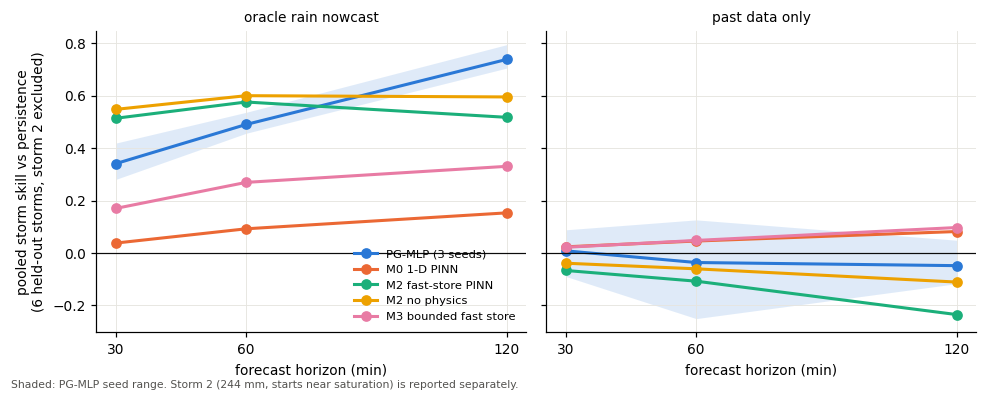

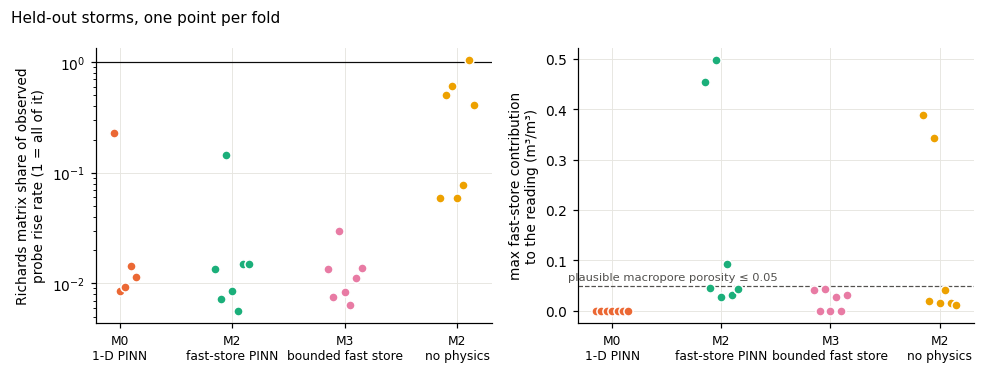

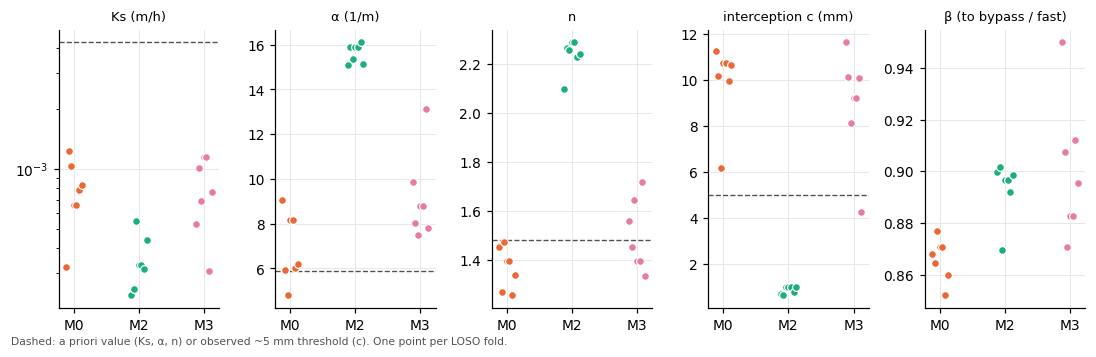

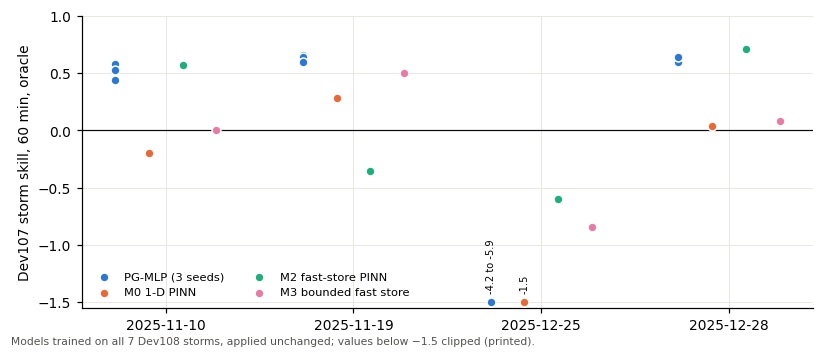

In [17]:
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.color': '#e6e5e0',
                     'grid.linewidth': 0.6, 'font.size': 9, 'figure.dpi': 110})
os.makedirs('figs', exist_ok=True)
COL = {'PG-MLP': '#2a78d6', 'M0': '#eb6834', 'M2': '#1baf7a', 'M2np': '#eda100', 'M3': '#e87ba4'}
LBL = {'PG-MLP': 'PG-MLP (3 seeds)', 'M0': 'M0 1-D PINN', 'M2': 'M2 fast-store PINN', 'M2np': 'M2 no physics', 'M3': 'M3 bounded fast store'}
HS = [30, 60, 120]

# Fig 7: LOSO skill by horizon, excluding storm 2
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
for k, mode in enumerate(['oracle', 'past']):
    s = SUM[SUM['mode'] == mode]
    pg = s[s.model.str.startswith('PG-MLP')]
    y = [pg[f'ex-s2 {h}'].mean() for h in HS]
    lo = [pg[f'ex-s2 {h}'].min() for h in HS]; hi = [pg[f'ex-s2 {h}'].max() for h in HS]
    ax[k].fill_between(HS, lo, hi, color=COL['PG-MLP'], alpha=0.15, lw=0)
    ax[k].plot(HS, y, '-o', color=COL['PG-MLP'], lw=2, ms=6, label=LBL['PG-MLP'])
    for mdl in ['M0', 'M2', 'M2np', 'M3']:
        r = s[s.model == mdl]
        if len(r):
            ax[k].plot(HS, [r[f'ex-s2 {h}'].iloc[0] for h in HS], '-o', color=COL[mdl], lw=2, ms=6, label=LBL[mdl])
    ax[k].axhline(0, color='#0b0b0b', lw=0.8); ax[k].set_xticks(HS); ax[k].set_xlabel('forecast horizon (min)')
    ax[k].set_title('oracle rain nowcast' if mode == 'oracle' else 'past data only', fontsize=9)
ax[0].set_ylabel('pooled storm skill vs persistence\n(6 held-out storms, storm 2 excluded)')
ax[0].legend(frameon=False, fontsize=7.5, loc='lower right')
fig.text(0.01, 0.01, 'Shaded: PG-MLP seed range. Storm 2 (244 mm, starts near saturation) is reported separately.', fontsize=7, color='#52514e')
fig.tight_layout(); fig.savefig('figs/fig7_loso_skill.png', dpi=300); plt.show()

# Fig 8: where the probe signal comes from
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
mods = [m for m in ['M0', 'M2', 'M3', 'M2np'] if m in set(D.model)]
for i, mdl in enumerate(mods):
    d = D[D.model == mdl]
    ax[0].scatter(np.full(len(d), i) + np.linspace(-0.15, 0.15, len(d)), d['matrix_share_wetup'].clip(lower=1e-3), s=36,
                  color=COL[mdl], edgecolor='white', lw=1, zorder=3)
    ax[1].scatter(np.full(len(d), i) + np.linspace(-0.15, 0.15, len(d)), d['fast_part_max'].fillna(0), s=36,
                  color=COL[mdl], edgecolor='white', lw=1, zorder=3)
for a in ax:
    a.set_xticks(range(len(mods))); a.set_xticklabels([LBL[m].replace(' ', '\n', 1) for m in mods], fontsize=8)
ax[0].set_yscale('log'); ax[0].axhline(1, color='#0b0b0b', lw=0.8)
ax[0].set_ylabel('Richards matrix share of observed\nprobe rise rate (1 = all of it)')
ax[1].axhline(0.05, color='#52514e', lw=0.8, ls='--'); ax[1].text(-0.4, 0.06, 'plausible macropore porosity ≤ 0.05', fontsize=7.5, color='#52514e')
ax[1].set_ylabel('max fast-store contribution\nto the reading (m³/m³)')
fig.suptitle('Held-out storms, one point per fold', x=0.01, ha='left', fontsize=10)
fig.tight_layout(); fig.savefig('figs/fig8_signal_source.png', dpi=300); plt.show()

# Fig 9: parameter spread across folds (H3)
P9 = PAR[PAR.fold != 'all']
pars = [('Ks_mph', 'Ks (m/h)', True, 0.0043), ('alpha', 'α (1/m)', False, 5.9), ('n', 'n', False, 1.48),
        ('c_mm', 'interception c (mm)', False, 5.0), ('beta', 'β (to bypass / fast)', False, None)]
fig, ax = plt.subplots(1, len(pars), figsize=(10, 3.2))
for j, (c, lab, lg, ref) in enumerate(pars):
    for i, mdl in enumerate(['M0', 'M2', 'M3']):
        d = P9[P9.model == mdl][c]
        ax[j].scatter(np.full(len(d), i) + np.linspace(-0.12, 0.12, len(d)), d, s=26, color=COL[mdl], edgecolor='white', lw=0.8, zorder=3)
    if ref is not None:
        ax[j].axhline(ref, color='#52514e', lw=0.9, ls='--')
    if lg:
        ax[j].set_yscale('log')
    ax[j].set_xticks(range(3)); ax[j].set_xticklabels(['M0', 'M2', 'M3']); ax[j].set_title(lab, fontsize=8.5)
fig.text(0.01, 0.01, 'Dashed: a priori value (Ks, α, n) or observed ~5 mm threshold (c). One point per LOSO fold.', fontsize=7, color='#52514e')
fig.tight_layout(); fig.savefig('figs/fig9_param_spread.png', dpi=300); plt.show()

# Fig 10: zero-shot Dev108 -> Dev107
z = ZS[ZS['mode'] == 'oracle'].copy(); z['fam'] = z.model.str.split(' ').str[0]
fig, ax = plt.subplots(figsize=(7.5, 3.2))
fams = ['PG-MLP', 'M0', 'M2', 'M3']
for j, fm in enumerate(fams):
    zz = z[z.fam == fm]
    for i in range(4):
        v = zz[f's{i}'].values
        ax.scatter(np.full(len(v), i + (j - 1.5) * 0.18), np.clip(v, -1.5, 1), s=34, color=COL[fm], edgecolor='white', lw=1,
                   label=LBL[fm] if i == 0 else None, zorder=3)
        clipped = v[v < -1.5]
        if len(clipped):
            lab = f'{clipped.max():.1f}' if len(clipped) == 1 else f'{clipped.max():.1f} to {clipped.min():.1f}'
            ax.text(i + (j - 1.5) * 0.18, -1.42, lab, rotation=90, fontsize=6.5, ha='center', va='bottom')
ax.axhline(0, color='#0b0b0b', lw=0.8); ax.set_ylim(-1.55, 1)
ax.set_xticks(range(4)); ax.set_xticklabels([f'{d.date()}' for d in S107.start])
ax.set_ylabel('Dev107 storm skill, 60 min, oracle'); ax.legend(frameon=False, fontsize=7.5, ncol=2, loc='lower left')
fig.text(0.01, 0.01, 'Models trained on all 7 Dev108 storms, applied unchanged; values below −1.5 clipped (printed).', fontsize=7, color='#52514e')
fig.tight_layout(); fig.savefig('figs/fig10_zeroshot.png', dpi=300); plt.show()
